In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Column names for the CMAPSS dataset
col_names = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor{i}' for i in range(1, 22)]

# Helper function to load train, test, and RUL files
def load_data(train_path, test_path, rul_path):
  train = pd.read_csv(train_path, sep='\s+', header=None, names=col_names)
  test = pd.read_csv(test_path, sep='\s+', header=None, names=col_names)
  rul = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])
  return train, test, rul

# Load all datasets into a dictionary
datasets_raw = {}
for i in range(1, 5):
  name = f'FD00{i}'
  datasets_raw[name] = load_data(f'/content/train_{name}.txt', f'/content/test_{name}.txt', f'/content/RUL_{name}.txt')

# Unpack datasets for individual access
train1, test1, rul1 = datasets_raw['FD001']
train2, test2, rul2 = datasets_raw['FD002']
train3, test3, rul3 = datasets_raw['FD003']
train4, test4, rul4 = datasets_raw['FD004']

In [3]:
# Check dataset dimensions and preview training data
print("FD001 train shape:", train1.shape)
print("FD001 test shape:", test1.shape)
train1.head()

FD001 train shape: (20631, 26)
FD001 test shape: (13096, 26)


,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# Descriptive statistics for the first training set
train1.describe()

,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


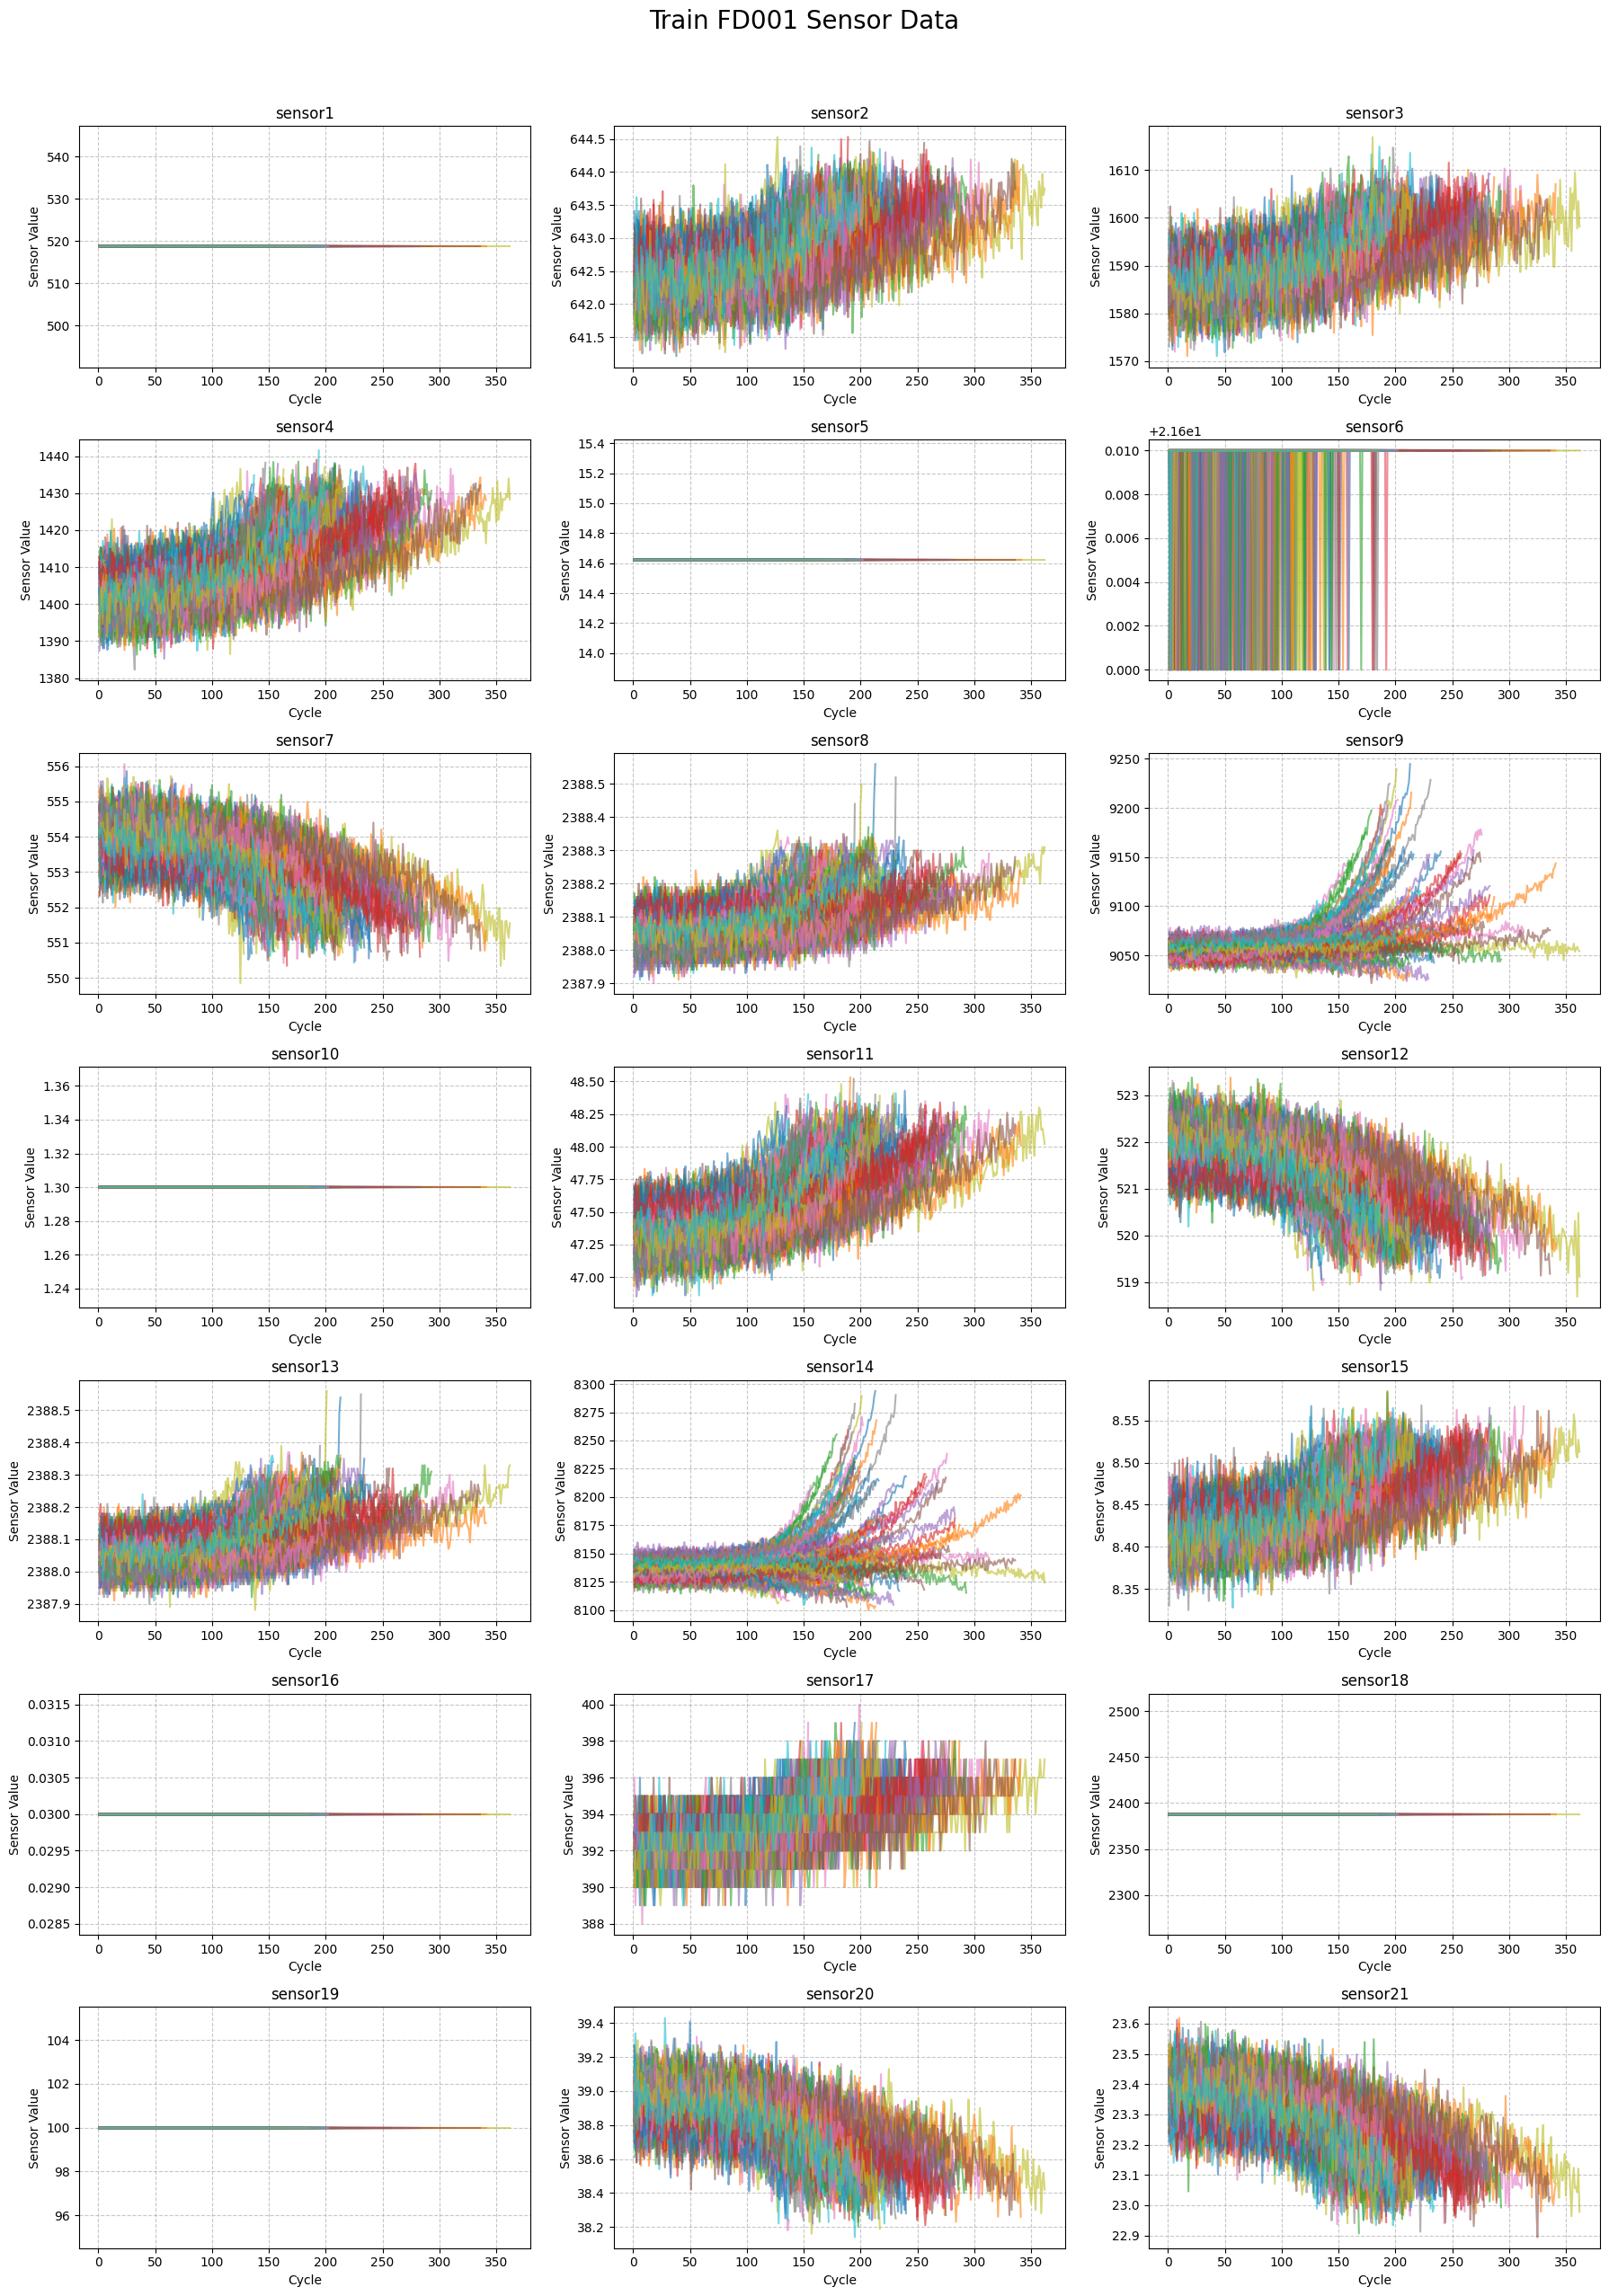

In [5]:
# Function to visualize sensor readings across all units
def plot_sensor_data(df, title):
  sensors = [f'sensor{i}' for i in range(1, 22)]
  num_sensors = len(sensors)

  fig, axes = plt.subplots(7, 3, figsize=(18, 25))
  fig.suptitle(title, fontsize=20, y=1.02)
  axes = axes.flatten()

  for i, sensor in enumerate(sensors):
    ax = axes[i]
    for unit in df['unit'].unique():
      unit_data = df[df['unit'] == unit]
      ax.plot(unit_data['cycle'], unit_data[sensor], alpha=0.6, label=f'Unit {unit}')
    ax.set_title(f'{sensor}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Sensor Value')
    ax.grid(True, linestyle='--', alpha=0.7)

  # Remove empty subplots
  for j in range(num_sensors, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

plot_sensor_data(train1, 'Train FD001 Sensor Data')

In [6]:
# Selecting sensors that are not constant
selected_sensors = ['sensor2','sensor3','sensor4','sensor7','sensor8',
                    'sensor9','sensor11','sensor12','sensor13','sensor14',
                    'sensor15','sensor17','sensor20','sensor21']

features = selected_sensors
max_rul = 125

# Calculate Remaining Useful Life (RUL) labels for training data
def add_rul_labels(df):
  max_cycle = df.groupby('unit')['cycle'].max().reset_index()
  max_cycle.columns = ['unit', 'max_cycle']
  df = df.merge(max_cycle, on='unit')
  df['RUL'] = df['max_cycle'] - df['cycle']
  df['RUL'] = df['RUL'].clip(upper=max_rul)
  df.drop(columns=['max_cycle'], inplace=True)
  return df

# Apply RUL labelling to all training sets
trains = [train1, train2, train3, train4]
train1, train2, train3, train4 = [add_rul_labels(t) for t in trains]

In [7]:
# Scale sensor features to range (-1, 1)
def normalize(train_df, test_df, features):
  scaler = MinMaxScaler(feature_range=(-1, 1))
  train_df = train_df.copy()
  test_df = test_df.copy()
  train_df[features] = scaler.fit_transform(train_df[features])
  test_df[features] = scaler.transform(test_df[features])
  return train_df, test_df, scaler

# Normalize all datasets independently
train1_n, test1_n, scaler1 = normalize(train1, test1, features)
train2_n, test2_n, scaler2 = normalize(train2, test2, features)
train3_n, test3_n, scaler3 = normalize(train3, test3, features)
train4_n, test4_n, scaler4 = normalize(train4, test4, features)

print("Normalized. Sample:")
train1_n[features].describe()

Normalized. Sample:


,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,-0.113895,-0.150507,-0.099130,0.132918,-0.404086,-0.609504,-0.177181,0.161394,-0.364258,-0.547810,-0.097764,-0.131558,0.048482,0.092255
std,0.301237,0.267327,0.303869,0.285054,0.215108,0.198177,0.317961,0.314522,0.211526,0.196885,0.288611,0.258127,0.280227,0.298953
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.328313,-0.336385,-0.321067,-0.046699,-0.545455,-0.718478,-0.404762,-0.031983,-0.529412,-0.656260,-0.307426,-0.333333,-0.131783,-0.095278
50%,-0.138554,-0.168956,-0.129305,0.156200,-0.424242,-0.650633,-0.214286,0.189765,-0.382353,-0.580968,-0.122740,-0.166667,0.069767,0.114885
75%,0.078313,0.017659,0.090648,0.339775,-0.272727,-0.572018,0.011905,0.390192,-0.235294,-0.500774,0.082724,0.000000,0.255814,0.305164
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# Window size for time-series sequences
window_size = 30

# Custom PyTorch Dataset for sliding window extraction
class CMAPSSDataset(Dataset):
  def __init__(self, df, features, window_size, is_train=True, rul_df=None):
    self.X, self.y = [], []

    if is_train:
      for unit_id, group in df.groupby('unit'):
        data = group[features].values
        rul  = group['RUL'].values
        for i in range(len(data) - window_size + 1):
          self.X.append(data[i:i+window_size])
          self.y.append(rul[i + window_size - 1])

    else:
      for unit_id, group in df.groupby('unit'):
        data = group[features].values
        if len(data) < window_size:
          pad = np.zeros((window_size - len(data), len(features)))
          data = np.vstack([pad, data])
        self.X.append(data[-window_size:])
      self.y = rul_df['RUL'].values.tolist()

    self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
    self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

  def __len__(self):
        return len(self.X)

  def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Helper to create datasets and data loaders
def make_datasets(train_df, test_df, rul_df, features, window_size):
  train_ds = CMAPSSDataset(train_df, features, window_size, is_train=True)
  test_ds = CMAPSSDataset(test_df,  features, window_size, is_train=False, rul_df=rul_df)
  return train_ds, test_ds

batch = 256

def make_loaders(train_ds, test_ds):
  return (DataLoader(train_ds, batch_size=batch, shuffle=True),
          DataLoader(test_ds,  batch_size=batch, shuffle=False))

# Prepare all data loaders
train_ds1, test_ds1 = make_datasets(train1_n, test1_n, rul1, features, window_size)
train_ds2, test_ds2 = make_datasets(train2_n, test2_n, rul2, features, window_size)
train_ds3, test_ds3 = make_datasets(train3_n, test3_n, rul3, features, window_size)
train_ds4, test_ds4 = make_datasets(train4_n, test4_n, rul4, features, window_size)

train_loader1, test_loader1 = make_loaders(train_ds1, test_ds1)
train_loader2, test_loader2 = make_loaders(train_ds2, test_ds2)
train_loader3, test_loader3 = make_loaders(train_ds3, test_ds3)
train_loader4, test_loader4 = make_loaders(train_ds4, test_ds4)

In [9]:
# LSTM model architecture for RUL estimation
class LSTMModel(nn.Module):
  def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
    super().__init__()

    self.lstm = nn.LSTM(
        input_size = input_size,
        hidden_size = hidden_size,
        num_layers = num_layers,
        batch_first = True,
        dropout = dropout
    )

    self.regressor = nn.Sequential(
       nn.Linear(hidden_size, 32),
       nn.ReLU(),
       nn.Dropout(0.2),
       nn.Linear(32, 1)
    )

  def forward(self, x):
    out, _ = self.lstm(x)
    out = out[:, -1, :]
    return self.regressor(out).squeeze(-1)

# Setup compute device and initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = LSTMModel(input_size=len(features)).to(device)

In [10]:
# Deep CNN model - Fixed with dynamic dimension calculation
class DCNNModel(nn.Module):
  def __init__(self, input_size, window_size, num_filters=10, filter_size=10, dropout=0.5):
    super().__init__()

    def conv_block(in_ch, out_ch, k):
      return nn.Sequential(
          nn.Conv2d(in_ch, out_ch, kernel_size=(k, 1), padding=(k//2, 0)),
          nn.Tanh()
      )

    self.conv_layers = nn.Sequential(
        conv_block(1, num_filters, filter_size),
        conv_block(num_filters, num_filters, filter_size),
        conv_block(num_filters, num_filters, filter_size),
        conv_block(num_filters, num_filters, filter_size),
        conv_block(num_filters, 1, 3),
    )
    self.dropout = nn.Dropout(dropout)

    # Dynamically calculate the flattened dimension
    with torch.no_grad():
      dummy_input = torch.zeros(1, 1, window_size, input_size)
      dummy_output = self.conv_layers(dummy_input)
      flat_dim = dummy_output.view(1, -1).size(1)

    self.regressor = nn.Sequential(
        nn.Linear(flat_dim, 100),
        nn.Tanh(),
        nn.Linear(100, 1)
    )

  def forward(self, x):
    x = x.unsqueeze(1) # Add channel dimension: (batch, 1, window_size, input_size)
    x = self.conv_layers(x)
    x = x.view(x.size(0), -1) # Flatten
    x = self.dropout(x)
    return self.regressor(x).squeeze(-1)

# Re-initialize the model
dcnn_model = DCNNModel(input_size=len(features), window_size=window_size).to(device)

In [11]:
# Encoder-Decoder model with reconstruction auxiliary loss
class RNNEncoderDecoder(nn.Module):
  def __init__(self, input_size, hidden_size=55, num_layers=1, dropout=0.2):
    super().__init__()

    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.encoder = nn.GRU(
        input_size = input_size,
        hidden_size = hidden_size,
        num_layers = num_layers,
        batch_first = True,
        dropout = dropout if num_layers > 1 else 0.0
    )

    self.decoder = nn.GRU(
        input_size = hidden_size,
        hidden_size = hidden_size,
        num_layers = num_layers,
        batch_first = True,
        dropout = dropout if num_layers > 1 else 0.0
    )

    self.decoder_output = nn.Linear(hidden_size, input_size)
    self.regressor = nn.Sequential(
        nn.Linear(hidden_size, 32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1)
    )

  def encode(self, x):
    _, h = self.encoder(x)
    return h[-1]

  def decode(self, embedding, seq_len):
    dec_input = embedding.unsqueeze(1).repeat(1, seq_len, 1)
    out, _ = self.decoder(dec_input, embedding.unsqueeze(0).repeat(self.num_layers, 1, 1))
    return self.decoder_output(out)

  def forward(self, x, return_reconstruction=False):
    embedding = self.encode(x)
    rul_pred  = self.regressor(embedding).squeeze(-1)
    if return_reconstruction:
      recon = self.decode(embedding, x.size(1))
      return rul_pred, recon
    return rul_pred

embed_rul_model = RNNEncoderDecoder(input_size=len(features)).to(device)

In [12]:
# Training loop supporting reconstruction loss
def train_model(model, train_loader, num_epochs=60, lr=1e-3,
                use_recon_loss=False, recon_weight=0.3):

  # Initialize optimizer and scheduler
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
  criterion = nn.MSELoss()

  history = []
  model.train()

  for epoch in range(num_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      optimizer.zero_grad()

      # Calculate loss
      if use_recon_loss:
        rul_pred, recon = model(X_batch, return_reconstruction=True)
        rul_loss = criterion(rul_pred, y_batch)
        recon_loss = criterion(recon, X_batch)
        loss = (1 - recon_weight)*rul_loss + recon_weight*recon_loss
      else:
        rul_pred = model(X_batch)
        loss = criterion(rul_pred, y_batch)

      # Backpropagation
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step()
      total_loss += loss.item()*len(X_batch)

    avg_loss = total_loss/len(train_loader.dataset)
    history.append(avg_loss)
    scheduler.step()

    if epoch == 0 or (epoch > 0 and epoch%10 == 0):
      print(f"Epoch {epoch} of {num_epochs} | Loss: {avg_loss:.4f}")

  return history

In [13]:
epochs = 50

# Train LSTM model
history_lstm = train_model(lstm_model, train_loader1, num_epochs=epochs)

Epoch 0 of 50 | Loss: 7518.2980
Epoch 10 of 50 | Loss: 332.6871
Epoch 20 of 50 | Loss: 293.8208
Epoch 30 of 50 | Loss: 279.9464
Epoch 40 of 50 | Loss: 258.1594


In [14]:
# Train Deep CNN model
history_dcnn = train_model(dcnn_model, train_loader1, num_epochs=epochs)

Epoch 0 of 50 | Loss: 6989.6065
Epoch 10 of 50 | Loss: 1751.2773
Epoch 20 of 50 | Loss: 422.1548
Epoch 30 of 50 | Loss: 320.7933
Epoch 40 of 50 | Loss: 253.8519


In [15]:
# Train Embed-RUL model
history_embed = train_model(embed_rul_model, train_loader1, num_epochs=epochs,
                            use_recon_loss=True, recon_weight=0.3)

Epoch 0 of 50 | Loss: 5362.8572
Epoch 10 of 50 | Loss: 213.8817
Epoch 20 of 50 | Loss: 202.4207
Epoch 30 of 50 | Loss: 190.3407
Epoch 40 of 50 | Loss: 185.8793


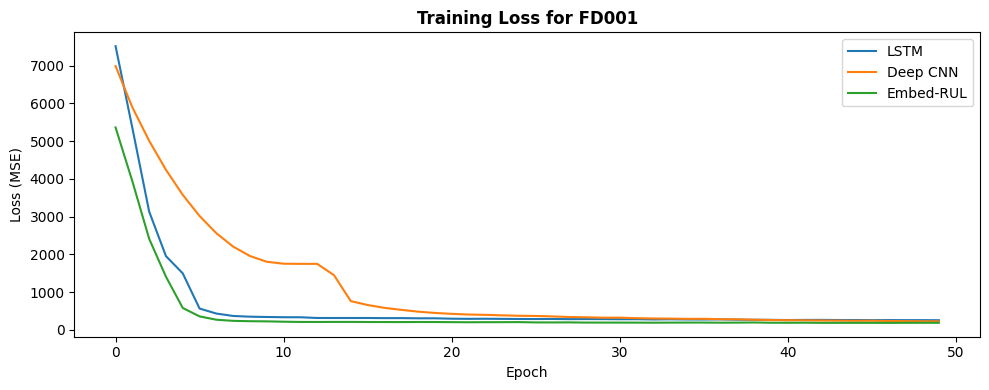

In [16]:
# Visualize training loss convergence for comparison
plt.figure(figsize=(10, 4))
plt.plot(history_lstm, label='LSTM')
plt.plot(history_dcnn, label='Deep CNN')
plt.plot(history_embed, label='Embed-RUL')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
plt.title('Training Loss for FD001', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Calculate RMSE and PHM asymmetric scoring metric
def evaluate_model(model, test_loader):
  model.eval()
  preds, targets = [], []
  with torch.no_grad():
    for X_batch, y_batch in test_loader:
      X_batch = X_batch.to(device)
      out = model(X_batch)
      if isinstance(out, tuple):
        out = out[0]
      preds.extend(out.cpu().numpy())
      targets.extend(y_batch.numpy())

  preds = np.clip(np.array(preds), 0, None)
  targets = np.array(targets)

  rmse = np.sqrt(np.mean((preds - targets)**2))
  d = preds - targets
  score = float(np.sum(np.where(d<0, np.exp(-d/13) - 1, np.exp(d/10) - 1)))
  return rmse, score, preds, targets

In [18]:
# Evaluate models on FD001 test set and display results table
rmse_lstm, score_lstm, preds_lstm, targets = evaluate_model(lstm_model, test_loader1)
rmse_dcnn, score_dcnn, preds_dcnn,  _ = evaluate_model(dcnn_model, test_loader1)
rmse_embed, score_embed, preds_embed, _ = evaluate_model(embed_rul_model, test_loader1)

results_data = {
    'Model': ['LSTM', 'Deep CNN', 'Embed-RUL'],
    'RMSE': [round(rmse_lstm, 4), round(rmse_dcnn, 4), round(rmse_embed, 4)],
    'PHM Score': [round(score_lstm, 2), round(score_dcnn, 2), round(score_embed, 2)]
}

display(pd.DataFrame(results_data))

,Model,RMSE,PHM Score
0,LSTM,15.5829,415.54
1,Deep CNN,14.7753,315.61
2,Embed-RUL,14.8567,374.60


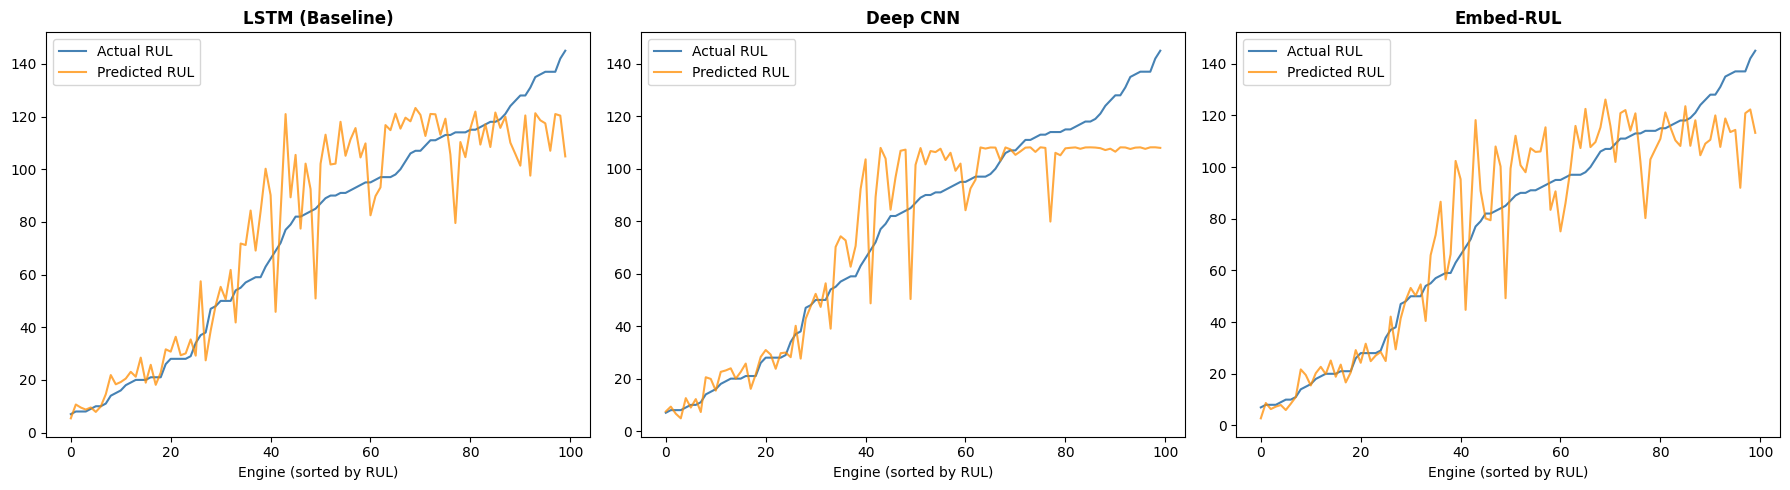

In [19]:
# Compare predicted vs actual RUL curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
names_preds = [('LSTM (Baseline)', preds_lstm),
               ('Deep CNN', preds_dcnn),
               ('Embed-RUL', preds_embed)]

sorted_idx = np.argsort(targets)

for ax, (name, preds) in zip(axes, names_preds):
  ax.plot(targets[sorted_idx], color='steelblue', label='Actual RUL')
  ax.plot(preds[sorted_idx], color='darkorange', alpha=0.75, label='Predicted RUL')
  ax.set_title(name, fontweight='bold')
  ax.set_xlabel('Engine (sorted by RUL)')
  ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Initialize results dictionary
results = {}

print('For dataset FD001:')
results['FD001'] = {}

# Train LSTM model
print('LSTM model')
m_lstm1 = LSTMModel(len(features)).to(device)
train_model(m_lstm1, train_loader1, num_epochs=epochs)
r_l1, s_l1, _, _ = evaluate_model(m_lstm1, test_loader1)
results['FD001']['LSTM'] = (r_l1, s_l1)

# Train Deep CNN model
print('\nDeep CNN model')
m_dcnn1 = DCNNModel(input_size=len(features), window_size=window_size).to(device)
train_model(m_dcnn1, train_loader1, num_epochs=epochs)
r_c1, s_c1, _, _ = evaluate_model(m_dcnn1, test_loader1)
results['FD001']['Deep CNN'] = (r_c1, s_c1)

# Train Embed-RUL model
print('\nEmbed-RUL model')
m_embed1 = RNNEncoderDecoder(input_size=len(features)).to(device)
train_model(m_embed1, train_loader1, num_epochs=epochs, use_recon_loss=True)
r_e1, s_e1, _, _ = evaluate_model(m_embed1, test_loader1)
results['FD001']['Embed-RUL'] = (r_e1, s_e1)

For dataset FD001:
LSTM model
Epoch 0 of 50 | Loss: 7660.1146
Epoch 10 of 50 | Loss: 357.9133
Epoch 20 of 50 | Loss: 312.5601
Epoch 30 of 50 | Loss: 309.0283
Epoch 40 of 50 | Loss: 293.2889

Deep CNN model
Epoch 0 of 50 | Loss: 7104.8650
Epoch 10 of 50 | Loss: 1751.5581
Epoch 20 of 50 | Loss: 431.6125
Epoch 30 of 50 | Loss: 341.6365
Epoch 40 of 50 | Loss: 277.5182

Embed-RUL model
Epoch 0 of 50 | Loss: 5414.2082
Epoch 10 of 50 | Loss: 255.1109
Epoch 20 of 50 | Loss: 197.1017
Epoch 30 of 50 | Loss: 197.1557
Epoch 40 of 50 | Loss: 185.3533


In [21]:
print('For dataset FD002:')
results['FD002'] = {}

# Train LSTM model
print('LSTM model')
m_lstm2 = LSTMModel(len(features)).to(device)
train_model(m_lstm2, train_loader2, num_epochs=epochs)
r_l2, s_l2, _, _ = evaluate_model(m_lstm2, test_loader2)
results['FD002']['LSTM'] = (r_l2, s_l2)

# Train Deep CNN model
print('\nDeep CNN model')
m_dcnn2 = DCNNModel(input_size=len(features), window_size=window_size).to(device)
train_model(m_dcnn2, train_loader2, num_epochs=epochs)
r_c2, s_c2, _, _ = evaluate_model(m_dcnn2, test_loader2)
results['FD002']['Deep CNN'] = (r_c2, s_c2)

# Train Embed-RUL model
print('\nEmbed-RUL model')
m_embed2 = RNNEncoderDecoder(input_size=len(features)).to(device)
train_model(m_embed2, train_loader2, num_epochs=epochs, use_recon_loss=True)
r_e2, s_e2, _, _ = evaluate_model(m_embed2, test_loader2)
results['FD002']['Embed-RUL'] = (r_e2, s_e2)

For dataset FD002:
LSTM model
Epoch 0 of 50 | Loss: 5901.9684
Epoch 10 of 50 | Loss: 558.2023
Epoch 20 of 50 | Loss: 418.6828
Epoch 30 of 50 | Loss: 397.2205
Epoch 40 of 50 | Loss: 369.8705

Deep CNN model
Epoch 0 of 50 | Loss: 6245.9608
Epoch 10 of 50 | Loss: 1747.1130
Epoch 20 of 50 | Loss: 1746.9956
Epoch 30 of 50 | Loss: 1747.1604
Epoch 40 of 50 | Loss: 1709.2528

Embed-RUL model
Epoch 0 of 50 | Loss: 4140.0653
Epoch 10 of 50 | Loss: 390.6935
Epoch 20 of 50 | Loss: 307.2086
Epoch 30 of 50 | Loss: 281.1142
Epoch 40 of 50 | Loss: 269.7057


In [22]:
print('For dataset FD003:')
results['FD003'] = {}

# Train LSTM model
print('LSTM model')
m_lstm3 = LSTMModel(len(features)).to(device)
train_model(m_lstm3, train_loader3, num_epochs=epochs)
r_l3, s_l3, _, _ = evaluate_model(m_lstm3, test_loader3)
results['FD003']['LSTM'] = (r_l3, s_l3)

# Train Deep CNN model
print('\nDeep CNN model')
m_dcnn3 = DCNNModel(input_size=len(features), window_size=window_size).to(device)
train_model(m_dcnn3, train_loader3, num_epochs=epochs)
r_c3, s_c3, _, _ = evaluate_model(m_dcnn3, test_loader3)
results['FD003']['Deep CNN'] = (r_c3, s_c3)

# Train Embed-RUL model
print('\nEmbed-RUL model')
m_embed3 = RNNEncoderDecoder(input_size=len(features)).to(device)
train_model(m_embed3, train_loader3, num_epochs=epochs, use_recon_loss=True)
r_e3, s_e3, _, _ = evaluate_model(m_embed3, test_loader3)
results['FD003']['Embed-RUL'] = (r_e3, s_e3)

For dataset FD003:
LSTM model
Epoch 0 of 50 | Loss: 8870.6517
Epoch 10 of 50 | Loss: 370.1203
Epoch 20 of 50 | Loss: 318.8776
Epoch 30 of 50 | Loss: 306.4583
Epoch 40 of 50 | Loss: 305.3104

Deep CNN model
Epoch 0 of 50 | Loss: 8151.1054
Epoch 10 of 50 | Loss: 1045.2737
Epoch 20 of 50 | Loss: 362.7697
Epoch 30 of 50 | Loss: 226.0164
Epoch 40 of 50 | Loss: 164.4684

Embed-RUL model
Epoch 0 of 50 | Loss: 5936.6664
Epoch 10 of 50 | Loss: 220.3445
Epoch 20 of 50 | Loss: 190.7645
Epoch 30 of 50 | Loss: 180.2349
Epoch 40 of 50 | Loss: 174.0297


In [23]:
print('For dataset FD004:')
results['FD004'] = {}

# Train LSTM model
print('LSTM model')
m_lstm4 = LSTMModel(len(features)).to(device)
train_model(m_lstm4, train_loader4, num_epochs=epochs)
r_l4, s_l4, _, _ = evaluate_model(m_lstm4, test_loader4)
results['FD004']['LSTM'] = (r_l4, s_l4)

# Train Deep CNN model
print('\nDeep CNN model')
m_dcnn4 = DCNNModel(input_size=len(features), window_size=window_size).to(device)
train_model(m_dcnn4, train_loader4, num_epochs=epochs)
r_c4, s_c4, _, _ = evaluate_model(m_dcnn4, test_loader4)
results['FD004']['Deep CNN'] = (r_c4, s_c4)

# Train Embed-RUL model
print('\nEmbed-RUL model')
m_embed4 = RNNEncoderDecoder(input_size=len(features)).to(device)
train_model(m_embed4, train_loader4, num_epochs=epochs, use_recon_loss=True)
r_e4, s_e4, _, _ = evaluate_model(m_embed4, test_loader4)
results['FD004']['Embed-RUL'] = (r_e4, s_e4)

For dataset FD004:
LSTM model
Epoch 0 of 50 | Loss: 6236.3931
Epoch 10 of 50 | Loss: 600.9349
Epoch 20 of 50 | Loss: 475.6150
Epoch 30 of 50 | Loss: 432.6156
Epoch 40 of 50 | Loss: 399.7297

Deep CNN model
Epoch 0 of 50 | Loss: 7180.9239
Epoch 10 of 50 | Loss: 965.7037
Epoch 20 of 50 | Loss: 713.0240
Epoch 30 of 50 | Loss: 643.8460
Epoch 40 of 50 | Loss: 576.5046

Embed-RUL model
Epoch 0 of 50 | Loss: 4613.5054
Epoch 10 of 50 | Loss: 406.5900
Epoch 20 of 50 | Loss: 342.6433
Epoch 30 of 50 | Loss: 312.8895
Epoch 40 of 50 | Loss: 294.2356


In [24]:
# Display evaluation metrics for all datasets and all models
for ds_name, models_data in results.items():
  print(f"Results for {ds_name}:")
  table_data = []
  # Iterate through all trained models in the results dictionary
  for model_name in ['LSTM', 'Deep CNN', 'Embed-RUL']:
    if model_name in models_data:
      rmse, score = models_data[model_name]
      table_data.append({
          'Model': model_name,
          'RMSE': f'{rmse:.4f}',
          'PHM Score': f'{score:.2f}'
      })

  if table_data:
    display(pd.DataFrame(table_data))
    print()
  else:
    print("No results available for this dataset yet.")

Results for FD001:


,Model,RMSE,PHM Score
0,LSTM,15.0353,345.27
1,Deep CNN,14.8217,288.80
2,Embed-RUL,14.3802,345.04



Results for FD002:


,Model,RMSE,PHM Score
0,LSTM,28.8507,22887.30
1,Deep CNN,42.0852,46119.26
2,Embed-RUL,29.8173,22343.42



Results for FD003:


,Model,RMSE,PHM Score
0,LSTM,14.7319,437.50
1,Deep CNN,14.1018,325.79
2,Embed-RUL,14.5517,340.05



Results for FD004:


,Model,RMSE,PHM Score
0,LSTM,30.2001,8217.56
1,Deep CNN,38.8709,67056.84
2,Embed-RUL,31.6249,14382.48


In [25]:
ds_names = list(datasets_raw.keys())
x = np.arange(len(ds_names))
width = 0.25

model_names = ['LSTM', 'Deep CNN', 'Embed-RUL']

sns.set_style('whitegrid')
colors = sns.color_palette('viridis', n_colors=len(model_names))

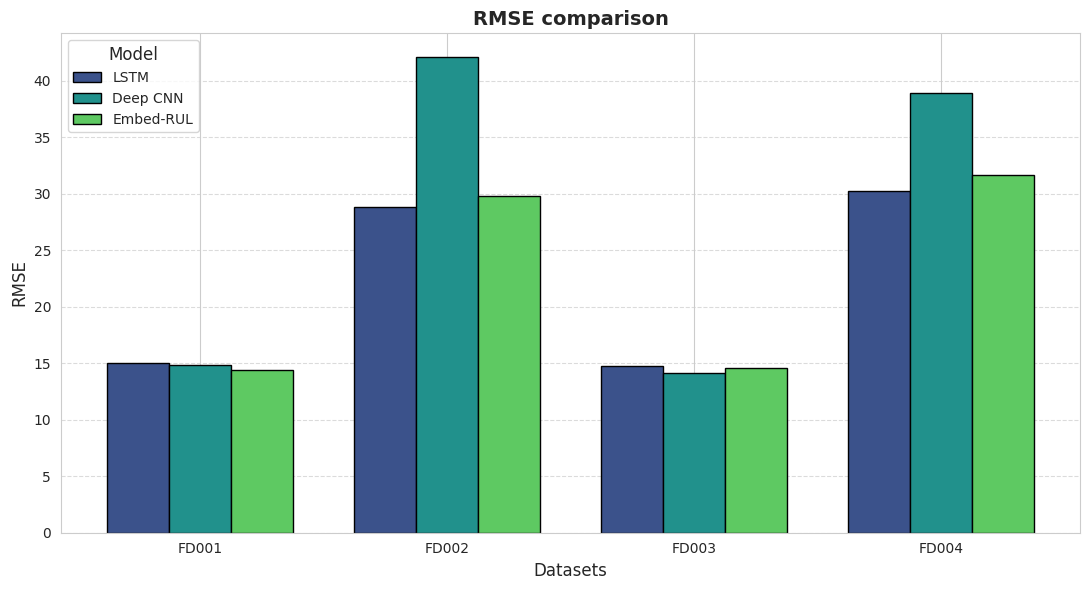

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))

for i, mname in enumerate(model_names):
  rmses = []
  for ds in ds_names:
    model_res = results.get(ds, {}).get(mname)
    if model_res:
      rmses.append(model_res[0])
    else:
      rmses.append(0)

  ax.bar(x + i*width, rmses, width, label=mname, color=colors[i], edgecolor='black')

ax.set_xlabel('Datasets', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('RMSE comparison', fontsize=14, fontweight='bold')

ax.set_xticks(x + (len(model_names) - 1)*width/2)
ax.set_xticklabels(ds_names, rotation=0, ha='center', fontsize=10)

ax.legend(title='Model', fontsize=10, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

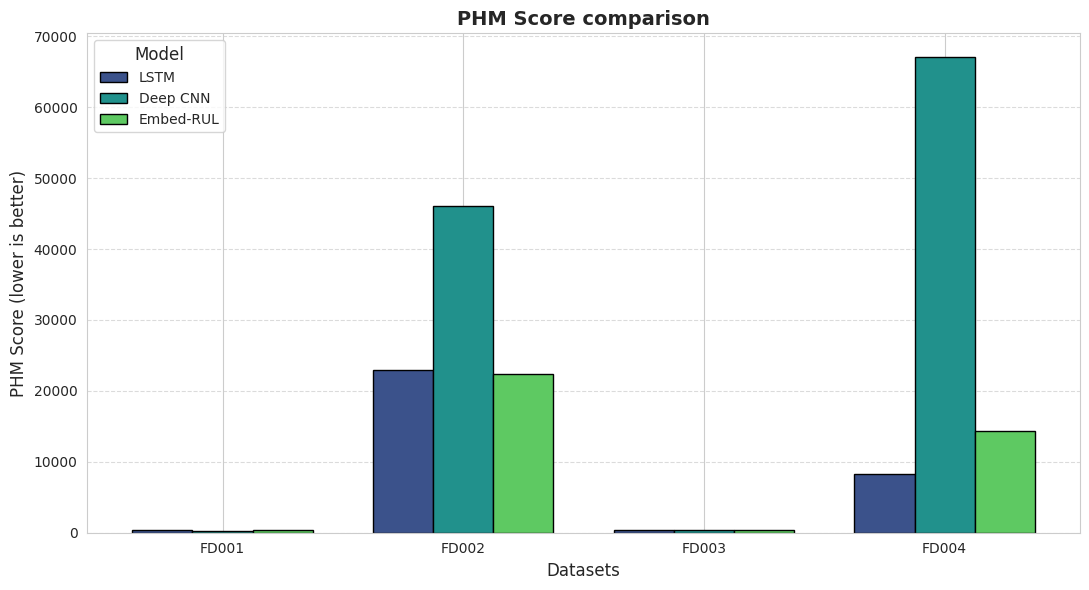

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))

for i, mname in enumerate(model_names):
  scores = [results.get(ds, {}).get(mname, (0,0))[1] for ds in ds_names]
  ax.bar(x + i*width, scores, width, label=mname,
         color=colors[i], edgecolor='black')

ax.set_xlabel('Datasets', fontsize=12)
ax.set_ylabel('PHM Score (lower is better)', fontsize=12)
ax.set_title('PHM Score comparison', fontsize=14, fontweight='bold')

ax.set_xticks(x + (len(model_names)-1)*width/2)
ax.set_xticklabels(ds_names, rotation=0, ha='center', fontsize=10)

ax.legend(title='Model', fontsize=10, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
torch.save(m_lstm1.state_dict(), 'lstm_fd001.pth')
torch.save(m_dcnn1.state_dict(), 'dcnn_fd001.pth')
torch.save(m_embed1.state_dict(), 'embed_rul_fd001.pth')

torch.save(m_lstm2.state_dict(), 'lstm_fd002.pth')
torch.save(m_dcnn2.state_dict(), 'dcnn_fd002.pth')
torch.save(m_embed2.state_dict(), 'embed_rul_fd002.pth')

torch.save(m_lstm3.state_dict(), 'lstm_fd003.pth')
torch.save(m_dcnn3.state_dict(), 'dcnn_fd003.pth')
torch.save(m_embed3.state_dict(), 'embed_rul_fd003.pth')

torch.save(m_lstm4.state_dict(), 'lstm_fd004.pth')
torch.save(m_dcnn4.state_dict(), 'dcnn_fd004.pth')
torch.save(m_embed4.state_dict(), 'embed_rul_fd004.pth')